# Сравнение русскоязычных моделей детекции фейков

Сравниваются **5 моделей**, обученных только на русском языке:

| Модель | Векторизация |
|--------|-------------|
| Naive Bayes | TF-IDF |
| Random Forest | TF-IDF |
| Logistic Regression | TF-IDF |
| Random Forest | Word2Vec |
| Logistic Regression | Word2Vec |
| **RuBERT** | Transformer (DeepPavlov/rubert-base-cased) |

Оценка на одном и том же тестовом наборе из `data/ready_dataset.csv`  
(split: `test_size=0.1, random_state=42`, стратификация по метке).

## 1. Импорты и конфигурация

In [1]:
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
from gensim.models import KeyedVectors
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import nltk
try:
    from nltk.corpus import stopwords
    RU_STOPWORDS = set(stopwords.words('russian'))
except LookupError:
    nltk.download('stopwords')
    from nltk.corpus import stopwords
    RU_STOPWORDS = set(stopwords.words('russian'))

os.makedirs('assets', exist_ok=True)

# ── Пути ──
DATA_PATH          = '../../data/ready_dataset.csv'
MODEL_NB_TFIDF     = '../../models/naive_bayes_model_tf.pkl'
MODEL_RF_TFIDF     = '../../models/random_forest_model_tf.pkl'
MODEL_LR_TFIDF     = '../../models/logistic_regression_model_tf.pkl'
TFIDF_VECTORIZER   = '../../models/tfidf_vectorizer_tf.pkl'
MODEL_RF_W2V       = '../../models/randomforest_model.pkl'
MODEL_LR_W2V       = '../../models/logisticregression_model.pkl'
W2V_VECTORS        = '../../models/w2v_vectors.kv'
RUBERT_DIR         = '../../models/rubert/best_model'
RUBERT_MAX_LEN     = 256

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')

Устройство: cpu


## 2. Предобработка текста

In [2]:
def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or len(text) == 0:
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in RU_STOPWORDS and len(w) > 2]
    return ' '.join(words)


def combine_features(headline_clean: str, body_clean: str) -> str:
    body_words = body_clean.split()[:500]
    return f"{headline_clean} {' '.join(body_words)}"

## 3. Загрузка данных и формирование тестовой выборки

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape}, колонки: {list(df.columns)}')
print(df['label'].value_counts().rename({0: 'fake (0)', 1: 'real (1)'}))

# Если нет готовой combined_text — строим из title/text
if 'combined_text' not in df.columns:
    title_col = 'title' if 'title' in df.columns else 'Headline'
    body_col  = 'text'  if 'text'  in df.columns else 'articleBody'
    df['headline_clean'] = df[title_col].apply(preprocess_text)
    df['body_clean']     = df[body_col].apply(preprocess_text)
    df['combined_text']  = df.apply(
        lambda r: combine_features(r['headline_clean'], r['body_clean']), axis=1
    )
    print('combined_text построен из сырых колонок')
else:
    print('combined_text уже есть в датасете')

# Тестовая выборка — тот же split, что использовался при обучении RuBERT
_, test_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['label']
)
test_df = test_df.reset_index(drop=True)
print(f'Тестовая выборка: {len(test_df)} примеров')
print(test_df['label'].value_counts().rename({0: 'fake', 1: 'real'}))

Датасет: (4408, 6), колонки: ['Unnamed: 0', 'headline_clean', 'body_clean', 'combined_text', 'text_length', 'label']
label
fake (0)    2221
real (1)    2187
Name: count, dtype: int64
combined_text уже есть в датасете
Тестовая выборка: 441 примеров
label
fake    222
real    219
Name: count, dtype: int64


## 4. Загрузка классических моделей (TF-IDF и Word2Vec)

In [4]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

tfidf_vec  = load_pickle(TFIDF_VECTORIZER)
nb_tfidf   = load_pickle(MODEL_NB_TFIDF)
rf_tfidf   = load_pickle(MODEL_RF_TFIDF)
lr_tfidf   = load_pickle(MODEL_LR_TFIDF)

kv_model   = KeyedVectors.load(W2V_VECTORS)
rf_w2v     = load_pickle(MODEL_RF_W2V)
lr_w2v     = load_pickle(MODEL_LR_W2V)

print('Все классические модели загружены')

Все классические модели загружены


## 5. Оценка моделей на TF-IDF

In [5]:
X_test_tfidf = tfidf_vec.transform(test_df['combined_text'])
y_true = test_df['label'].values

tfidf_models = {
    'Naive Bayes (TF-IDF)':          nb_tfidf,
    'Random Forest (TF-IDF)':        rf_tfidf,
    'Logistic Regression (TF-IDF)':  lr_tfidf,
}

results = {}

for name, model in tfidf_models.items():
    y_pred = model.predict(X_test_tfidf)
    results[name] = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }
    print(f"{name}:")
    print(classification_report(y_true, y_pred, digits=4))

Naive Bayes (TF-IDF):
              precision    recall  f1-score   support

           0     0.9110    0.9685    0.9389       222
           1     0.9659    0.9041    0.9340       219

    accuracy                         0.9365       441
   macro avg     0.9384    0.9363    0.9364       441
weighted avg     0.9382    0.9365    0.9364       441

Random Forest (TF-IDF):
              precision    recall  f1-score   support

           0     0.9372    0.9414    0.9393       222
           1     0.9404    0.9361    0.9382       219

    accuracy                         0.9388       441
   macro avg     0.9388    0.9388    0.9388       441
weighted avg     0.9388    0.9388    0.9388       441

Logistic Regression (TF-IDF):
              precision    recall  f1-score   support

           0     0.9394    0.9775    0.9581       222
           1     0.9762    0.9361    0.9557       219

    accuracy                         0.9569       441
   macro avg     0.9578    0.9568    0.9569       44

## 6. Оценка моделей на Word2Vec

In [6]:
def doc_vector(tokens, kv, max_len=150):
    if isinstance(tokens, str):
        tokens = tokens.split()[:max_len]
    else:
        tokens = tokens[:max_len]
    vecs = [kv[w] for w in tokens if w in kv]
    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)


def cosine_sim(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    return 0.0 if nu == 0 or nv == 0 else float(np.dot(u, v) / (nu * nv))


def jaccard(a, b):
    A, B = set(a), set(b)
    return 0.0 if not A and not B else len(A & B) / max(1, len(A | B))


def overlap(a, b):
    A, B = set(a), set(b)
    return 0.0 if not A else len(A & B) / len(A)


def build_w2v_features(df_in, kv, title_col='title', body_col='text', max_len=150):
    """Строит W2V-фичи. Если raw-колонок нет, разбивает combined_text пополам."""
    rows = []
    for _, row in df_in.iterrows():
        if title_col in df_in.columns and body_col in df_in.columns:
            h_text = preprocess_text(str(row[title_col]))
            b_text = preprocess_text(str(row[body_col]))
        else:
            tokens = str(row.get('combined_text', '')).split()
            mid = max(1, len(tokens) // 4)  # первая четверть — «заголовок»
            h_text = ' '.join(tokens[:mid])
            b_text = ' '.join(tokens[mid:])

        h_tok = h_text.split()[:max_len]
        b_tok = b_text.split()[:max_len]
        hvec = doc_vector(h_tok, kv)
        bvec = doc_vector(b_tok, kv)

        cos  = cosine_sim(hvec, bvec)
        jacc = jaccard(h_tok, b_tok)
        ovr  = overlap(h_tok, b_tok)
        diff = np.abs(hvec - bvec)
        prod = hvec * bvec
        l2   = np.linalg.norm(hvec - bvec)

        feat = np.hstack([hvec, bvec, diff, prod, cos, jacc, ovr, l2])
        rows.append(feat)
    return np.vstack(rows)


print('Строим W2V-признаки для тестовой выборки...')
X_test_w2v = build_w2v_features(test_df, kv_model)
print(f'X_test_w2v shape: {X_test_w2v.shape}')

w2v_models = {
    'Random Forest (W2V)':       rf_w2v,
    'Logistic Regression (W2V)': lr_w2v,
}

for name, model in w2v_models.items():
    y_pred = model.predict(X_test_w2v)
    results[name] = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }
    print(f"{name}:")
    print(classification_report(y_true, y_pred, digits=4))

Строим W2V-признаки для тестовой выборки...
X_test_w2v shape: (441, 1204)
Random Forest (W2V):
              precision    recall  f1-score   support

           0     0.9052    0.9459    0.9251       222
           1     0.9426    0.8995    0.9206       219

    accuracy                         0.9229       441
   macro avg     0.9239    0.9227    0.9228       441
weighted avg     0.9238    0.9229    0.9229       441

Logistic Regression (W2V):
              precision    recall  f1-score   support

           0     0.8498    0.9685    0.9053       222
           1     0.9628    0.8265    0.8894       219

    accuracy                         0.8980       441
   macro avg     0.9063    0.8975    0.8973       441
weighted avg     0.9059    0.8980    0.8974       441



## 7. Оценка RuBERT

In [7]:
rubert_tokenizer = AutoTokenizer.from_pretrained(RUBERT_DIR)
rubert_model = AutoModelForSequenceClassification.from_pretrained(RUBERT_DIR).to(DEVICE)
rubert_model.eval()
print('RuBERT загружен')


@torch.no_grad()
def predict_rubert(text: str):
    enc = rubert_tokenizer(
        str(text).strip(),
        truncation=True, padding='max_length',
        max_length=RUBERT_MAX_LEN, return_tensors='pt'
    )
    out = rubert_model(
        input_ids=enc['input_ids'].to(DEVICE),
        attention_mask=enc['attention_mask'].to(DEVICE)
    )
    probs = torch.softmax(out.logits, dim=1).cpu().numpy()[0]
    return int(np.argmax(probs))


from tqdm.auto import tqdm

y_pred_rubert = [
    predict_rubert(text)
    for text in tqdm(test_df['combined_text'], desc='RuBERT inference')
]

results['RuBERT'] = {
    'accuracy':  accuracy_score(y_true, y_pred_rubert),
    'f1':        f1_score(y_true, y_pred_rubert, pos_label=1, zero_division=0),
    'precision': precision_score(y_true, y_pred_rubert, pos_label=1, zero_division=0),
    'recall':    recall_score(y_true, y_pred_rubert, pos_label=1, zero_division=0),
}
print(classification_report(y_true, y_pred_rubert, digits=4))

RuBERT загружен


RuBERT inference: 100%|██████████| 441/441 [01:39<00:00,  4.43it/s]

              precision    recall  f1-score   support

           0     0.9907    0.9595    0.9748       222
           1     0.9602    0.9909    0.9753       219

    accuracy                         0.9751       441
   macro avg     0.9754    0.9752    0.9751       441
weighted avg     0.9755    0.9751    0.9751       441



## 8. Сводная таблица метрик

In [8]:
metrics_df = pd.DataFrame(results).T.rename_axis('Модель').reset_index()
metrics_df = metrics_df.sort_values('f1', ascending=False).reset_index(drop=True)

# Форматирование
for col in ['accuracy', 'f1', 'precision', 'recall']:
    metrics_df[col] = metrics_df[col].map(lambda x: f'{x:.4f}')

metrics_df.columns = ['Модель', 'Accuracy', 'F1', 'Precision', 'Recall']
metrics_df.index = range(1, len(metrics_df) + 1)

display(metrics_df)
metrics_df.to_csv('../../assets/russian_models_comparison.csv', index=False, encoding='utf-8')
print('Таблица сохранена в assets/russian_models_comparison.csv')

,Модель,Accuracy,F1,Precision,Recall
1,RuBERT,0.9751,0.9753,0.9602,0.9909
2,Logistic Regression (TF-IDF),0.9569,0.9557,0.9762,0.9361
3,Random Forest (TF-IDF),0.9388,0.9382,0.9404,0.9361
4,Naive Bayes (TF-IDF),0.9365,0.9340,0.9659,0.9041
5,Random Forest (W2V),0.9229,0.9206,0.9426,0.8995
6,Logistic Regression (W2V),0.8980,0.8894,0.9628,0.8265


Таблица сохранена в assets/russian_models_comparison.csv


## 9. Визуализация метрик

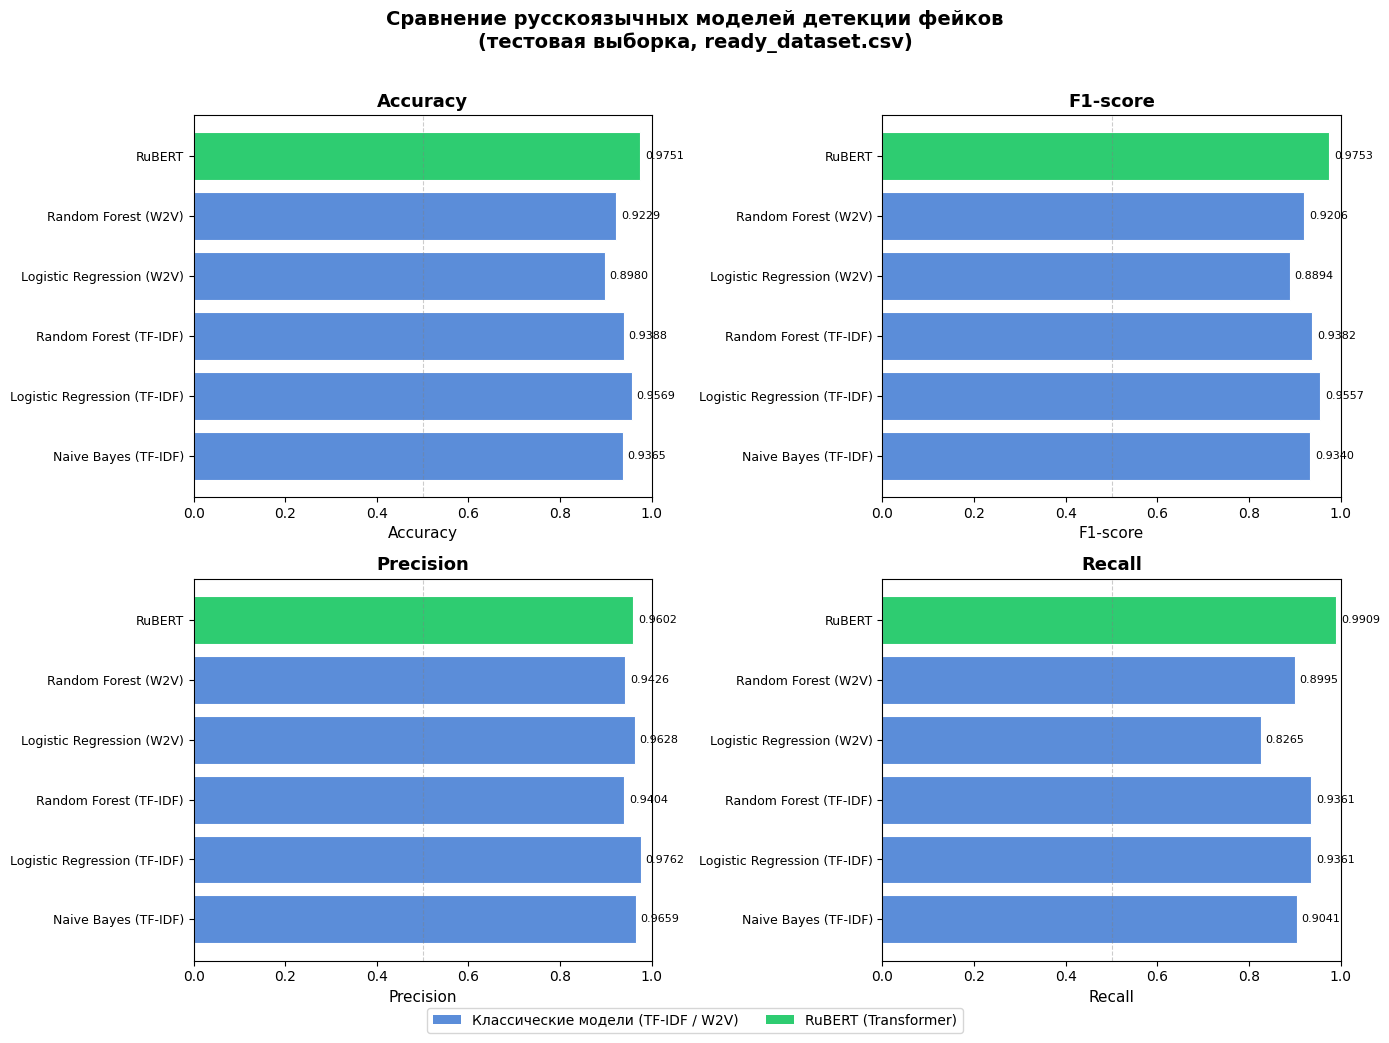

График сохранён в assets/russian_models_comparison.png


In [9]:
# Восстанавливаем числовые значения из results
models_order = [
    'Naive Bayes (TF-IDF)',
    'Logistic Regression (TF-IDF)',
    'Random Forest (TF-IDF)',
    'Logistic Regression (W2V)',
    'Random Forest (W2V)',
    'RuBERT',
]
# Сортируем по наличию в results
models_order = [m for m in models_order if m in results]

metric_names = ['accuracy', 'f1', 'precision', 'recall']
metric_labels = ['Accuracy', 'F1-score', 'Precision', 'Recall']
colors = ['#5b8dd9', '#5b8dd9', '#5b8dd9', '#5b8dd9', '#5b8dd9', '#2ecc71']
colors = colors[:len(models_order)]  # обрезаем до нужного размера
# Перекрашиваем RuBERT
if 'RuBERT' in models_order:
    colors[models_order.index('RuBERT')] = '#2ecc71'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric, label in zip(axes, metric_names, metric_labels):
    vals = [results[m][metric] for m in models_order]
    bars = ax.barh(models_order, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5b8dd9', label='Классические модели (TF-IDF / W2V)'),
    Patch(facecolor='#2ecc71', label='RuBERT (Transformer)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Сравнение русскоязычных моделей детекции фейков\n(тестовая выборка, ready_dataset.csv)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../assets/russian_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('График сохранён в assets/russian_models_comparison.png')

## 10. Матрицы ошибок

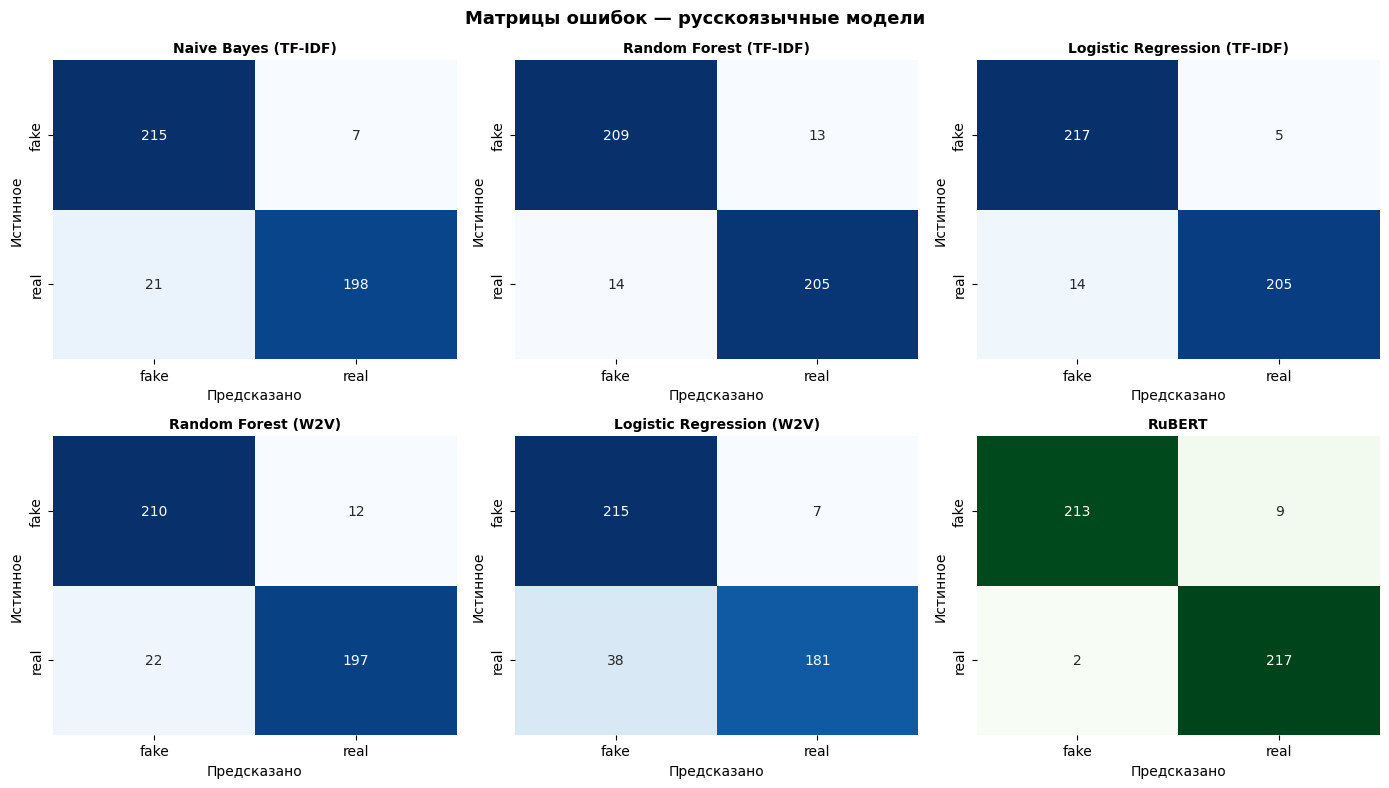

Матрицы сохранены в assets/russian_models_confusion_matrices.png


In [10]:
# Пересчитываем предсказания для confusion matrix
all_preds = {}

for name, model in tfidf_models.items():
    all_preds[name] = model.predict(X_test_tfidf)

for name, model in w2v_models.items():
    all_preds[name] = model.predict(X_test_w2v)

all_preds['RuBERT'] = y_pred_rubert

n_models = len(all_preds)
ncols = 3
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_true, preds)
    color = 'Greens' if name == 'RuBERT' else 'Blues'
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=['fake', 'real'], yticklabels=['fake', 'real'],
                ax=ax, cbar=False)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинное')

# Скрываем лишние оси
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Матрицы ошибок — русскоязычные модели', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../assets/russian_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Матрицы сохранены в assets/russian_models_confusion_matrices.png')